In [1]:
import implicit

In [2]:
!wget http://files.grouplens.org/datasets/movielens/ml-20m.zip
!unzip ml-20m.zip

"wget" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.
"unzip" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.


In [2]:
import urllib.request
import zipfile
import os

url = "http://files.grouplens.org/datasets/movielens/ml-20m.zip"
zip_path = "ml-20m.zip"

# скачать
urllib.request.urlretrieve(url, zip_path)

# распаковать
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

print("Готово")


Готово


In [3]:
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix
import numpy as np
from implicit.als import AlternatingLeastSquares
import os
import time
from typing import List, Tuple
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [4]:
movies = pd.read_csv('ml-20m/movies.csv')
ratings = pd.read_csv('ml-20m/ratings.csv')

<Axes: xlabel='rating', ylabel='Count'>

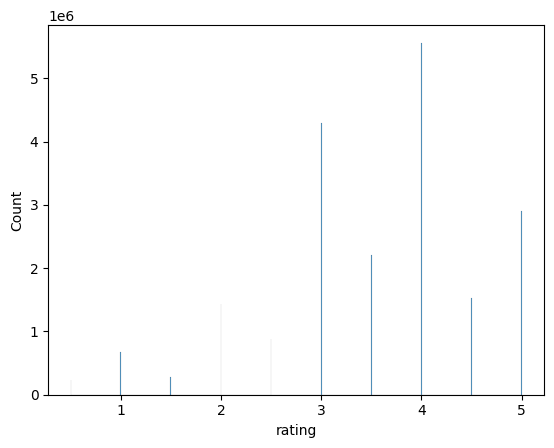

In [5]:
sns.histplot(ratings['rating'])

<Axes: ylabel='Count'>

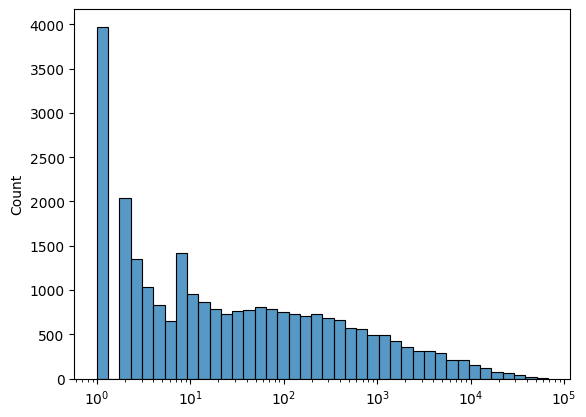

In [6]:
sns.histplot(ratings.groupby('movieId').size(),log_scale=True)

In [7]:
user_encoder,item_encoder = LabelEncoder(),LabelEncoder()
ratings['userId'] = user_encoder.fit_transform(ratings['userId'])
ratings['movieId'] = item_encoder.fit_transform(ratings['movieId'])

In [8]:
ratings.shape

(20000263, 4)

## Splitting data to train and test

In [9]:
def split_data_by_user(data,test_size = 0.3):
  """Last n interaction of each user is used as test data

  Args:
      data (pd.DataFrame): The data to split
      test_size (float, optional): The size of the test set. Defaults to 0.3.
  """
  train_data,test_data = [],[]
  data = data.sort_values(by='timestamp')

  for user_id, user_data in data.groupby('userId'):
    threshold = int(data.shape[0] * test_size)
    train_data.append(user_data.iloc[:-threshold])
    test_data.append(user_data.iloc[-threshold:])


  train_data = pd.concat(train_data)
  test_data = pd.concat(test_data)
  return train_data,test_data


def split_data_by_time(data,test_size = 0.3):
  """Split data by timestamp

  Args:
      data (pd.DataFrame): The data to split
      test_size (float, optional): The size of the test set. Defaults to 0.3.
  """
  data = data.sort_values(by='timestamp')
  threshold = int(data.shape[0] * test_size)
  return data.iloc[:-threshold], data.iloc[-threshold:]

In [30]:
train,df_test = split_data_by_time(ratings,0.2)
df_cand, df_rank = split_data_by_time(train,0.5)

In [112]:
def get_als_pred(data,users_to_recommend,N):
  model = AlternatingLeastSquares(factors=10, regularization=0.5, alpha=10,
                                  iterations=15)

  rows = data['userId'].values
  cols = data['movieId'].values
  values = data['rating'].values

  sparse_matrix = csr_matrix((values,(rows,cols)))
  model.fit(sparse_matrix)


  items_ids,scores = model.recommend(users_to_recommend,
                                     sparse_matrix[users_to_recommend],N = N,
                                     filter_already_liked_items=True)

  df_cand_preds = pd.DataFrame({'userId': [i for i in users_to_recommend for j in range(N)],
                                'movieId':[j for i in items_ids for j in i],
                                'als_rating':[j for i in scores for j in i]})
  return df_cand_preds

In [110]:
intersect = np.intersect1d(df_cand.userId.unique(),df_rank.userId.unique())
df_als_recs = df_rank[df_rank.userId.isin(intersect)]
df_cand_preds = get_als_pred(df_cand,intersect,200)

  0%|          | 0/15 [00:00<?, ?it/s]

In [44]:
df_cand_preds

,userId,movieId,als_rating
0,23,1657,1.092256
1,23,3091,1.086511
2,23,1729,1.081694
3,23,178,1.079502
4,23,3653,1.077115
...,...,...,...
851595,138476,3626,0.741803
851596,138476,3527,0.741737
851597,138476,2270,0.741428
851598,138476,3382,0.741036


In [34]:
from catboost import CatBoost, Pool

In [45]:
df_cand_preds = pd.merge(df_cand_preds, ratings[['movieId','userId','rating']],
                         on=['userId','movieId'],how='left').fillna(0)

In [46]:
def get_pool(df):
  df = df.sort_values(by = ['userId','movieId'])

  group_id = df['userId'].values
  y = df['rating'].values

  pool = Pool(data = df[['userId','movieId','als_rating']],
              group_id = group_id,
              label = y,
              cat_features = None
              )
  return pool

In [47]:
all_users = df_cand_preds['userId'].unique()
np.random.shuffle(all_users)
threshold = int(0.2*len(all_users))
eval_users,test_users,train_users, = all_users[:threshold],all_users[threshold:threshold*2],all_users[2*threshold:]

In [48]:
eval_pool = get_pool(df_cand_preds[df_cand_preds['userId'].isin(eval_users)])
test_pool = get_pool(df_cand_preds[df_cand_preds['userId'].isin(test_users)])
train_pool = get_pool(df_cand_preds[df_cand_preds['userId'].isin(train_users)])

In [62]:
params = {'boosting_type':'Plain',
          'devices':'0',
          'early_stopping_rounds':100,
          'eval_metric':'RecallAt:top=50',
          'learning_rate':0.1,
          'max_ctr_complexity':1,
          'nan_mode':'Min',
          'num_trees':2000,
          'objective':'PairLogitPairwise',
          'random_state':52,
          'task_type':'GPU'
          }
ranker = CatBoost(params = params)

In [63]:
ranker.fit(X=train_pool,metric_period=100,eval_set = eval_pool)

Metric RecallAt:top=50 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.3670996	test: 0.3440258	best: 0.3440258 (0)	total: 411ms	remaining: 13m 42s
100:	learn: 0.4383578	test: 0.4169803	best: 0.4177746 (95)	total: 14.4s	remaining: 4m 31s
200:	learn: 0.4415694	test: 0.4143196	best: 0.4189429 (110)	total: 28.9s	remaining: 4m 18s
bestTest = 0.4189428914
bestIteration = 110
Shrink model to first 111 iterations.


In [106]:
ranker.eval_metrics(test_pool, metrics=["RecallAt:top=40"],ntree_start=ranker.tree_count_-1 )

{'RecallAt:top=40': [0.3802232579070379]}

In [107]:
ranker.predict(df_cand_preds)

array([ 0.08105922, -0.05370842,  0.08105922, ..., -2.58586987,
       -2.68518426, -2.4365678 ], shape=(851600,))

In [108]:
df_cand_preds

,userId,movieId,als_rating,rating
0,23,1657,1.092256,0.0
1,23,3091,1.086511,0.0
2,23,1729,1.081694,0.0
3,23,178,1.079502,0.0
4,23,3653,1.077115,0.0
...,...,...,...,...
851595,138476,3626,0.741803,0.0
851596,138476,3527,0.741737,0.0
851597,138476,2270,0.741428,0.0
851598,138476,3382,0.741036,0.0


In [64]:
tags = pd.read_csv('ml-20m/tags.csv')
tags

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,1240597180
1,65,208,dark hero,1368150078
2,65,353,dark hero,1368150079
3,65,521,noir thriller,1368149983
4,65,592,dark hero,1368150078
...,...,...,...,...
465559,138446,55999,dragged,1358983772
465560,138446,55999,Jason Bateman,1358983778
465561,138446,55999,quirky,1358983778
465562,138446,55999,sad,1358983772


In [76]:
tags['tag'] = LabelEncoder().fit_transform(tags['tag'])

In [95]:
df_cand_preds_tags = pd.merge(df_cand_preds,tags[['movieId','tag']],
         on = ['movieId'],how = 'inner').drop_duplicates(['movieId','userId'])

In [96]:
df_cand_preds_tags

,userId,movieId,als_rating,rating,tag
0,23,1657,1.092256,0.0,23879
1,23,3091,1.086511,0.0,19785
31,23,1729,1.081694,0.0,16396
177,23,178,1.079502,0.0,18525
185,23,3653,1.077115,0.0,35718
...,...,...,...,...,...
45370876,138476,1194,0.742065,0.0,23738
45370907,138476,3626,0.741803,0.0,37051
45370918,138476,3527,0.741737,0.0,29382
45371127,138476,2270,0.741428,0.0,12352


In [102]:
all_users = df_cand_preds_tags['userId'].unique()
np.random.shuffle(all_users)
threshold = int(0.2*len(all_users))
eval_users,test_users,train_users, = all_users[:threshold],all_users[threshold:threshold*2],all_users[2*threshold:]
eval_pool = get_pool(df_cand_preds_tags[df_cand_preds_tags['userId'].isin(eval_users)])
test_pool = get_pool(df_cand_preds_tags[df_cand_preds_tags['userId'].isin(test_users)])
train_pool = get_pool(df_cand_preds_tags[df_cand_preds_tags['userId'].isin(train_users)])

new_ranker = CatBoost(params = params)
new_ranker.fit(X=train_pool,metric_period=100,eval_set = eval_pool)

Metric RecallAt:top=50 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.3953270	test: 0.4031610	best: 0.4031610 (0)	total: 283ms	remaining: 9m 25s
100:	learn: 0.4838442	test: 0.4867130	best: 0.4867435 (99)	total: 10.4s	remaining: 3m 15s
200:	learn: 0.4875390	test: 0.4880511	best: 0.4885118 (196)	total: 20.3s	remaining: 3m 1s
300:	learn: 0.4903748	test: 0.4867810	best: 0.4887655 (271)	total: 30.5s	remaining: 2m 52s
bestTest = 0.4887655011
bestIteration = 271
Shrink model to first 272 iterations.


In [103]:
movies['genres'] = LabelEncoder().fit_transform(movies['genres'])
df_cand_preds_mov = pd.merge(df_cand_preds,movies[['movieId','genres']],
                             on = 'movieId',how = 'inner').drop_duplicates(['userId','movieId'])

In [104]:
all_users = df_cand_preds_mov['userId'].unique()
np.random.shuffle(all_users)
threshold = int(0.2*len(all_users))
eval_users,test_users,train_users, = all_users[:threshold],all_users[threshold:threshold*2],all_users[2*threshold:]
eval_pool = get_pool(df_cand_preds_mov[df_cand_preds_mov['userId'].isin(eval_users)])
test_pool = get_pool(df_cand_preds_mov[df_cand_preds_mov['userId'].isin(test_users)])
train_pool = get_pool(df_cand_preds_mov[df_cand_preds_mov['userId'].isin(train_users)])

mov_ranker = CatBoost(params = params)
mov_ranker.fit(X=train_pool,metric_period=100,eval_set = eval_pool)

Metric RecallAt:top=50 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.3650415	test: 0.3555423	best: 0.3555423 (0)	total: 331ms	remaining: 11m 2s
100:	learn: 0.4448480	test: 0.4349826	best: 0.4349826 (100)	total: 13.4s	remaining: 4m 12s
200:	learn: 0.4494191	test: 0.4368493	best: 0.4373296 (170)	total: 26.8s	remaining: 3m 59s
300:	learn: 0.4518039	test: 0.4379701	best: 0.4387960 (264)	total: 39.6s	remaining: 3m 43s
bestTest = 0.4387959986
bestIteration = 264
Shrink model to first 265 iterations.


In [105]:
df_test

,userId,movieId,rating,timestamp
911852,6098,6420,4.0,1256024035
911866,6098,6529,3.5,1256024055
912229,6098,12262,4.0,1256024058
911395,6098,2988,4.0,1256024067
911867,6098,6550,4.5,1256024126
...,...,...,...,...
7819902,53929,24832,3.5,1427781651
2508834,16977,2009,3.5,1427781797
12898546,89080,12118,3.5,1427782286
12898527,89080,11782,4.0,1427782288


In [ ]:
# from sqlalchemy import create_engine

# engine = create_engine('sqlite:///example.db', echo=True)
# ratings.to_sql('ratings', con=engine, if_exists='replace', index=False)
# movies.to_sql('movies', con=engine, if_exists='replace', index=False)

In [ ]:
import sqlite3
con = sqlite3.connect("example.db")
cur = con.cursor()
res = cur.execute("SELECT * FROM ratings LIMIT 5")
res.fetchall()

In [ ]:
res = cur.execute("SELECT * FROM ratings LIMIT 5")
res.fetchall()
# pd.DataFrame(res.fetchall(),columns=['movieId','title','genres'])

In [ ]:
def split_data(
    ratings: pd.DataFrame,
) -> Tuple[sp._csr.csr_matrix, List[Tuple[float, float, float]]]:
    """Splitting dataset into train and test

    Args:
        ratings (pd.DataFrame): The ratings data

    Returns:
        Tuple[sp._csr.csr_matrix, List[Tuple[float, float, float]]]: The train and test datasets
    """
    user_item_matrix = ratings.pivot(
        index="userId", columns="movieId", values="rating"
    ).fillna(0)

    # Convert to sparse matrix
    ratings_csr = csr_matrix(user_item_matrix.values)

    # Select 20% of users randomly
    np.random.seed(52)
    unique_users = ratings["userId"].unique()
    test_users = np.random.choice(
        unique_users, size=int(0.5 * len(unique_users)), replace=False
    )

    # Prepare train and test data
    train_data = ratings_csr.copy().toarray()
    test_data = []

    for user in test_users:
        user_index = np.where(unique_users == user)[0][0]
        user_ratings = np.where(train_data[user_index] > 0)[0]
        if len(user_ratings) > 0:
            test_item = np.random.choice(user_ratings)
            test_data.append((user_index, test_item, train_data[user_index, test_item]))
            train_data[user_index, test_item] = 0  # Remove one rating

    train_data = csr_matrix(train_data)
    return train_data, test_data

In [ ]:
train_data, test_data = split_data(ratings)

In [ ]:
train_data, len(test_data)

In [ ]:
model = AlternatingLeastSquares(factors=10, regularization=0.5, alpha=10,iterations=15)
model.fit(coo_matrix(ratings))

In [111]:
import joblib
joblib.dump(new_ranker, 'model_ranker.pkl')

['model_ranker.pkl']

In [ ]:
download_model = joblib.load('model.pkl')
download_model.recommend(0,csr_utils[0],10,filter_already_liked_items=False)

In [ ]:
def mse(item_emb,user_emb,test_data):
  test_predictions = []

  for user_index, item_index, true_rating in test_data:
      predicted_rating = np.dot(user_emb[user_index], item_emb[item_index])
      test_predictions.append((user_index, item_index, true_rating, predicted_rating))

  mse = np.mean([(true - pred) ** 2 for (_, _, true, pred) in test_predictions])
  return mse
def precision_at_k()
print(f"Test MSE: {mse(model.item_factors,model.user_factors,test_data)}")

In [ ]:
item_factors.shape

In [ ]:
test_predictions

In [ ]:
def get_top_k_recommendations_implicit(model, train_data, k=10):
    """Get top-k recommendations for users with implicit library"""
    user_factors = model.user_factors
    item_factors = model.item_factors
    scores = np.dot(user_factors, item_factors.T)
    scores[train_data.nonzero()] = -np.inf  # Exclude already interacted items
    top_k_items = np.argsort(scores, axis=1)[:, -k:][:, ::-1]
    top_k_scores = np.take_along_axis(scores, top_k_items, axis=1)
    return top_k_items, top_k_scores


(
    top_10_recommendations_implicit,
    top_10_scores_implicit,
) = get_top_k_recommendations_implicit(model, train_data, k=10)

In [ ]:
def mrr_at_k(predictions: np.ndarray, ground_truth: List[Tuple[int, int]], k: int = 10):
    """Calculate Mean Reciprocal Rank at K (MRR@K)"""
    mrr = 0.0
    for user_index, true_item in ground_truth:
        top_k_items = predictions[user_index][:k]

        if true_item in top_k_items:
            rank = np.where(top_k_items == true_item)[0][0] + 1
            mrr += 1.0 / rank

    mrr /= len(ground_truth)
    return mrr

In [ ]:
ground_truth = [(user_index, item_index) for user_index, item_index, _ in test_data]
mrr_10_implicit = mrr_at_k(top_10_recommendations_implicit, ground_truth, k=10)
print(f"MRR@10 for `implicit` realization: {mrr_10_implicit}")

In [ ]:
!pip install git+https://github.com/daviddavo/lightfm
import numpy as np
from lightfm.datasets import fetch_movielens
from lightfm import LightFM

In [ ]:
data = fetch_movielens(min_rating=3.0)
print(repr(data['train']))
print(repr(data['test']))

In [ ]:
%time
from scipy.sparse import coo_matrix
model = LightFM(loss='bpr')
model.fit(data['train'], epochs=50, num_threads=2)

In [ ]:
model.user_embeddings @ model.item_embeddings.T

In [ ]:
data['train'].toarray()

In [ ]:
model.item_embeddings.shape

In [ ]:
from lightfm.evaluation import precision_at_k
print("Train precision: %.2f" % precision_at_k(model, coo_matrix(ratings), k=10).mean())
# print("Test precision: %.2f" % precision_at_k(model, coo_matrix(test_data), k=10).mean())

In [ ]:
precision_at_k(model, data['train'], k=10)

In [ ]:
data['train']

In [ ]:
data['item_labels']

In [ ]:
def sample_recommendation(model, data, user_ids):

    n_users, n_items = data['train'].shape

    for user_id in user_ids:
        known_positives = data['item_labels'][data['train'].tocsr()[user_id].indices]

        scores = model.predict(user_id, np.arange(n_items))
        top_items = data['item_labels'][np.argsort(-scores)]

        print("User %s" % user_id)
        print("     Known positives:")

        for x in known_positives[:3]:
            print("        %s" % x)

        print("     Recommended:")

        for x in top_items[:3]:
            print("        %s" % x)

sample_recommendation(model, data, [3, 25, 450])